# 03 — YOLO26 bên trong: dự đoán dày đặc, NMS, đầu ra một-một, fine-tune

Notebook 02 chấm bộ nhận diện như một hộp đen. Notebook này mở hộp ra ở đúng những chỗ dự án
chạm tới: mạng đưa ra bao nhiêu dự đoán, vì sao cần NMS, đầu ra "không cần NMS" của YOLO26 làm
gì khác, và fine-tune đã thay đổi những gì. Code chạy mạng YOLO26n trên **CPU với một ảnh**, nên
nhẹ.

| Mục | Câu hỏi |
|---|---|
| 1. Dự đoán dày đặc | Vì sao mạng trả về đúng 10.920 dự đoán cho một ảnh KITTI? |
| 2. Vì sao có trùng lặp | Một chiếc xe sinh ra bao nhiêu dự đoán? |
| 3. NMS | Thuật toán, tự cài và so với thư viện |
| 4. Đầu ra một-một | YOLO26 bỏ NMS bằng cách nào? |
| 5. Fine-tune | Học chuyển giao, dừng sớm, chọn epoch |
| 6. Dấu hiệu quá khớp | Khung trên ảnh đã học có khít hơn ảnh mới không? |
| 7. Đầu ra một-một sau fine-tune | Vì sao nó thua đầu ra có NMS? |

In [1]:
import json
from pathlib import Path

import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from ultralytics.data.augment import LetterBox
from torchvision.ops import nms as torchvision_nms

from monodist import kitti
from monodist.detect import merge

torch.set_num_threads(4)
ROOT = Path("../data/kitti_tracking")
plt.rcParams.update({"figure.figsize": (9, 3.2), "figure.dpi": 110})

model = YOLO("../weights/yolo26n.pt")           # COCO weights, 80 classes
net = model.model.eval()
head = net.model[-1]
img = cv2.imread(str(kitti.image_path(ROOT, "0012", 0)))
print("image", img.shape, "| parameters", sum(p.numel() for p in net.parameters()))

image (375, 1242, 3) | parameters 2572280


## 1. Dự đoán dày đặc

**Ý tưởng của bộ nhận diện một giai đoạn.** Mạng tích chập biến ảnh thành vài **bản đồ đặc
trưng** nhỏ dần. Mỗi ô của mỗi bản đồ ứng với một vùng ảnh và **tự dự đoán**: một khung bao và
một điểm cho từng lớp. Không có bước "đề xuất vùng" riêng như các bộ nhận diện hai giai đoạn
đời cũ; mọi ô dự đoán song song trong một lần chạy mạng.

YOLO26 dùng ba bản đồ với **bước nhảy** (stride) 8, 16 và 32 pixel: bản đồ bước 8 có ô nhỏ,
hợp với vật nhỏ; bước 32 hợp với vật lớn.

**Ký hiệu mới**
- **stride** $s$: một ô của bản đồ ứng với $s \times s$ pixel của ảnh đầu vào

**Số dự đoán.** Ảnh KITTI $1242\times375$ được co theo cạnh dài về 1280, thành $1280 \times 387$,
rồi đệm thêm lên $1280\times416$ cho chia hết 32 (kỹ thuật **letterbox**: co giữ tỉ lệ, phần
thiếu tô màu xám). Số ô:

$$\frac{1280}{8}\cdot\frac{416}{8} + \frac{1280}{16}\cdot\frac{416}{16} + \frac{1280}{32}\cdot\frac{416}{32}
= 160\cdot52 + 80\cdot26 + 40\cdot13 = 8320 + 2080 + 520 = 10\,920.$$

Chạy mạng và kiểm tra:

strides: [8.0, 16.0, 32.0] | letterbox scale 1.0306, top padding 15.0 px
raw output (84, 10920) -> 4 box numbers + 80 class scores for each of 10920 cells


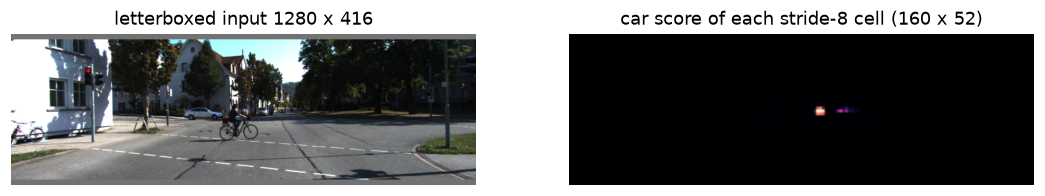

In [2]:
lb = LetterBox((416, 1280), auto=False)(image=img)
x = torch.from_numpy(lb[:, :, ::-1].copy()).permute(2, 0, 1)[None].float() / 255
scale = min(1280 / img.shape[1], 416 / img.shape[0])
pad_top = (416 - round(img.shape[0] * scale)) / 2
print("strides:", head.stride.tolist(), "| letterbox scale %.4f, top padding %.1f px" % (scale, pad_top))

head.end2end = False                              # the one-to-many head: every cell predicts
with torch.no_grad():
    raw = net(x)[0][0]                            # (4 + 80, cells)
print("raw output", tuple(raw.shape), "-> 4 box numbers + 80 class scores for each of", raw.shape[1], "cells")

car_score = raw[4 + 2].numpy()                    # COCO class 2 = car
grid8 = car_score[:160 * 52].reshape(52, 160)     # the first 8,320 cells are the stride-8 map
fig, axes = plt.subplots(1, 2, figsize=(12, 2.6))
axes[0].imshow(lb[:, :, ::-1]); axes[0].set_title("letterboxed input 1280 x 416"); axes[0].axis("off")
axes[1].imshow(grid8, cmap="magma"); axes[1].set_title("car score of each stride-8 cell (160 x 52)"); axes[1].axis("off")
plt.show()

## 2. Vì sao có trùng lặp

Nhìn bản đồ điểm: quanh mỗi chiếc xe có **cả một cụm ô** cùng sáng. Các ô cạnh nhau nhìn thấy
gần như cùng một vùng ảnh, nên cùng tự tin rằng ở đó có xe, và mỗi ô dự đoán một khung hơi
khác nhau. Đếm số dự đoán "car" có điểm trên 0,25:

In [3]:
xywh = raw[:4].T.numpy()
boxes = np.c_[xywh[:, 0] - xywh[:, 2] / 2, xywh[:, 1] - xywh[:, 3] / 2,
              xywh[:, 0] + xywh[:, 2] / 2, xywh[:, 1] + xywh[:, 3] / 2]      # centre/size -> corners
keep = car_score > 0.25
cand_box, cand_score = boxes[keep], car_score[keep]
print(f"{keep.sum()} cells say 'car' with score > 0.25; the frame has 2 labelled cars and 2 small cars in a DontCare region")

21 cells say 'car' with score > 0.25; the frame has 2 labelled cars and 2 small cars in a DontCare region


## 3. NMS

**Định nghĩa.** Non-maximum suppression (triệt tiêu điểm không cực đại) giữ lại, trong mỗi cụm
khung chồng nhau, khung có điểm cao nhất:

1. Xếp các khung theo điểm giảm dần.
2. Lấy khung đầu danh sách, đưa vào kết quả.
3. Xoá khỏi danh sách mọi khung có IoU với nó vượt ngưỡng (Ultralytics dùng 0,7).
4. Lặp lại từ bước 2 đến khi danh sách rỗng.

**Chi phí.** Mỗi vòng so một khung với mọi khung còn lại, nên trường hợp xấu là $O(n^2)$ với $n$
khung ứng viên. Nó chạy **ngoài mạng nơ-ron**, sau khi mạng xong. Ở notebook 06 bước này tốn
khoảng 1 ms trên T4.

**Ký hiệu mới**
- $O(n^2)$: số phép tính tăng theo bình phương số khung ứng viên

Tự cài bằng numpy và so với `torchvision.ops.nms`:

In [4]:
def nms(box, score, iou_threshold=0.7):
    order = np.argsort(-score)
    kept = []
    while len(order):
        i, rest = order[0], order[1:]
        kept.append(i)
        ix = np.clip(np.minimum(box[i, 2], box[rest, 2]) - np.maximum(box[i, 0], box[rest, 0]), 0, None)
        iy = np.clip(np.minimum(box[i, 3], box[rest, 3]) - np.maximum(box[i, 1], box[rest, 1]), 0, None)
        inter = ix * iy
        area = lambda b: (b[..., 2] - b[..., 0]) * (b[..., 3] - b[..., 1])
        order = rest[inter / (area(box[i]) + area(box[rest]) - inter) <= iou_threshold]
    return np.array(kept)

mine = nms(cand_box, cand_score)
ref = torchvision_nms(torch.tensor(cand_box), torch.tensor(cand_score), 0.7).numpy()
print("kept by my NMS:", mine.tolist(), "| by torchvision:", ref.tolist(), "| identical:", np.array_equal(mine, ref))

# back from the letterboxed 1280 x 416 input to the original image, then compare with Ultralytics' own pipeline
to_image = lambda b: np.c_[b[:, 0] / scale, (b[:, 1] - pad_top) / scale, b[:, 2] / scale, (b[:, 3] - pad_top) / scale]
r = model.predict(img, imgsz=(416, 1280), conf=0.25, classes=[2], nms=None, verbose=False)[0]
print("my NMS, image coordinates:\n", np.round(to_image(cand_box[mine]), 1), np.round(cand_score[mine], 3))
print("Ultralytics predict (nms=None):\n", np.round(r.boxes.xyxy.numpy(), 1), np.round(r.boxes.conf.numpy(), 3))

kept by my NMS: [11, 16, 5] | by torchvision: [11, 16, 5] | identical: True


my NMS, image coordinates:
 [[      459.5       181.9       568.2       215.1]
 [      654.6       180.6       685.8       205.8]
 [      715.6       186.5       732.4       196.7]] [      0.818       0.589       0.313]
Ultralytics predict (nms=None):
 [[      459.5       181.9       568.2       215.1]
 [      654.6       180.6       685.8       205.8]
 [      715.6       186.5       732.4       196.7]] [      0.818       0.589       0.313]


Hai mươi mốt ứng viên co lại còn ba khung, **trùng khớp hoàn toàn** với kết quả của Ultralytics
sau khi đổi toạ độ từ ảnh letterbox về ảnh gốc (chia cho hệ số co, trừ phần đệm phía trên).

## 4. Đầu ra một-một: YOLO26 bỏ NMS bằng cách nào

Trùng lặp sinh ra từ **cách huấn luyện**. Khi học, mỗi vật thật được gán cho **nhiều** ô
(gán một-nhiều, one-to-many): nhiều ô cùng được dạy "ở đây có xe". Cách này cho nhiều tín hiệu
học, nhưng dạy mạng sinh trùng lặp, nên cần NMS.

YOLO26 (theo ý tưởng của YOLOv10) có **thêm một đầu ra** huấn luyện bằng gán **một-một**
(one-to-one): mỗi vật chỉ được gán cho **đúng một** ô tốt nhất, mọi ô khác bị dạy là "không có
gì". Đầu ra này học được cách tự không trùng lặp, nên khi dùng nó thì bỏ được NMS, và kết quả là
tối đa 300 khung đã sắp xếp. Hai đầu ra dùng chung thân mạng và được huấn luyện cùng lúc.

In [5]:
head.end2end = True
with torch.no_grad():
    top = net(x)[0][0].numpy()                    # (300, 6): x1, y1, x2, y2, score, class
cars = top[(top[:, 5] == 2) & (top[:, 4] > 0.25)]
print("one-to-one head, output", top.shape, "-> cars above 0.25, image coordinates:")
print(np.round(to_image(cars[:, :4]), 1), np.round(cars[:, 4], 3))

one-to-one head, output (300, 6) -> cars above 0.25, image coordinates:
[[        459       182.1       568.6       215.2]
 [      655.2       180.6       684.7       205.6]
 [      715.3       185.7         732       196.4]] [      0.921       0.469       0.316]


Cùng ba chiếc xe, không cần NMS, nhưng **điểm khác** (0,92; 0,47; 0,32 so với 0,82; 0,59; 0,31):
hai đầu ra là hai bộ tham số khác nhau. Với trọng số COCO, hai đầu ra cho mAP gần như bằng nhau
trên KITTI (0,413 và 0,414).

**Ký hiệu mới**
- **end-to-end** (đầu cuối): dự đoán cuối cùng ra thẳng từ mạng, không qua bước hậu xử lý như NMS

## 5. Fine-tune

**Học chuyển giao (transfer learning).** Mạng đã học trên COCO (khoảng 118 nghìn ảnh, 80 lớp)
biết sẵn cạnh, hình dạng, bánh xe, dáng người. Thay vì học lại từ đầu, ta khởi tạo từ trọng số
đó rồi **huấn luyện tiếp trên dữ liệu đích** (KITTI). Dự án fine-tune **toàn bộ** khoảng 2,6
triệu tham số (ô code đầu notebook đếm cả hai đầu ra; đầu ra một-một chiếm 0,15 triệu; con số 2,4
triệu của nhà phát triển là mạng đã bỏ một đầu ra và gộp lớp batch norm vào lớp tích chập), không đóng băng lớp nào, vì mạng đủ nhỏ để bộ nhớ không phải là vấn đề.

Những gì thay đổi so với lúc huấn luyện trên COCO:
- **Lớp đầu ra**: 80 lớp thành 2 (Car, Pedestrian). Phần dự đoán lớp được khởi tạo lại; phần còn
  lại giữ trọng số COCO.
- **Ảnh**: 4.512 khung của 8 chuỗi train, kích thước 1280, tăng cường dữ liệu mặc định của
  Ultralytics (ghép 4 ảnh thành một, lật ngang, đổi màu).

**Dừng sớm và chọn epoch.** Sau mỗi epoch, Ultralytics chấm trên **tập val** và giữ bản có
**fitness** cao nhất, với fitness $= 0{,}1\cdot\text{mAP}_{50} + 0{,}9\cdot\text{mAP}_{50\text{–}95}$.
Nếu 10 epoch liền không cải thiện thì dừng (patience = 10).

**Ký hiệu mới**
- **epoch**: một lượt đi qua toàn bộ ảnh train · **patience**: số epoch chờ trước khi dừng sớm

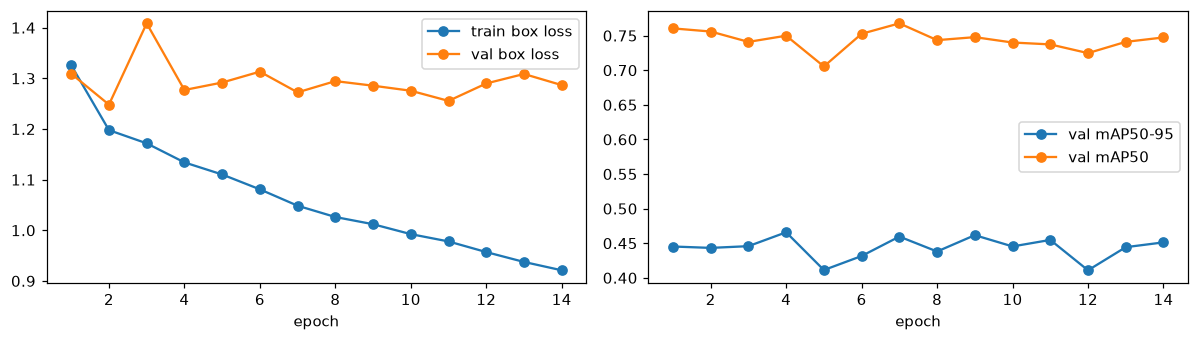

best epoch by fitness: 4 | val mAP50-95 0.466
validation during training used nms: ['nms: null']


In [6]:
import csv
rows = list(csv.DictReader(open("../results/finetune/results.csv")))
ep = [int(r["epoch"]) for r in rows]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(ep, [float(r["train/box_loss"]) for r in rows], marker="o", label="train box loss")
axes[0].plot(ep, [float(r["val/box_loss"]) for r in rows], marker="o", label="val box loss")
axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(ep, [float(r["metrics/mAP50-95(B)"]) for r in rows], marker="o", label="val mAP50-95")
axes[1].plot(ep, [float(r["metrics/mAP50(B)"]) for r in rows], marker="o", label="val mAP50")
axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout(); plt.show()
best = max(rows, key=lambda r: 0.1 * float(r["metrics/mAP50(B)"]) + 0.9 * float(r["metrics/mAP50-95(B)"]))
print("best epoch by fitness:", best["epoch"], "| val mAP50-95 %.3f" % float(best["metrics/mAP50-95(B)"]))
args = open("../results/finetune/args.yaml").read()
print("validation during training used nms:", [l for l in args.splitlines() if l.startswith("nms:")])

Hai điều đáng chú ý:
- **Loss train giảm đều, loss val và mAP val đi ngang ngay từ epoch 1.** Mạng đã thích nghi với
  KITTI gần như ngay lập tức; các epoch sau chủ yếu học thuộc tập train. Epoch tốt nhất là 4,
  dừng ở 14.
- Khi chấm val trong lúc huấn luyện, Ultralytics dùng `nms: null`, tức **đầu ra một-nhiều cộng
  NMS**. Epoch được chọn là epoch tốt nhất cho đầu ra *đó*; không có gì chọn cho đầu ra một-một.

## 6. Dấu hiệu quá khớp: khung khít hơn trên ảnh đã học

Một bộ nhận diện đã thấy ảnh train thì trên chính những ảnh đó khung của nó khít hơn thực tế.
Điều này quan trọng vì mạng đo khoảng cách (notebook 04) học trên khung của bộ nhận diện trên
tập train. Đo IoU trung vị giữa khung dự đoán và khung nhãn của những vật được ghép:

In [7]:
for c in ("coco_1280", "ft_1280_nms"):
    r = json.loads(Path(f"../results/eval/{c}.json").read_text())["box_iou_median"]
    print(f"{c:12s} median IoU  train {r['train']:.3f}  val {r['val']:.3f}  test {r['test']:.3f}")

coco_1280    median IoU  train 0.806  val 0.814  test 0.826
ft_1280_nms  median IoU  train 0.879  val 0.851  test 0.864


- Bộ nhận diện COCO chưa từng thấy KITTI: ba tập ngang nhau (khoảng 0,81).
- Bản fine-tune khít hơn hẳn ở mọi tập (0,85–0,88), và trên **tập train** khít hơn tập test khoảng
  1,5 điểm. Có quá khớp, nhưng nhỏ. Đó là lý do dự án vẫn huấn luyện mạng khoảng cách trên tập
  train (nhiều dữ liệu hơn tập val) và ghi lại con số này để người đọc tự đánh giá.

## 7. Đầu ra một-một sau fine-tune

Với trọng số COCO, hai đầu ra ngang nhau. Sau fine-tune thì không:

In [8]:
for c in ("coco_1280", "coco_1280_nms", "ft_1280", "ft_1280_nms"):
    r = json.loads(Path(f"../results/eval/{c}.json").read_text())
    det, sizes = merge(f"../results/det/{c}")
    m = np.isin(det["seq"], kitti.SPLIT["test"]) & (det["score"] >= r["conf"]["Car"])
    H = np.array([sizes[s][0] for s in det["seq"][m]])
    at_bottom = np.mean(det["box"][m, 3] >= H - 2)
    print(f"{c:14s} mAP50-95 {r['detection']['mAP50-95']:.3f} | kept boxes touching the bottom edge: {at_bottom:5.1%}")
labels = np.concatenate([kitti.load_labels(ROOT, s)["box"][np.isin(kitti.load_labels(ROOT, s)["type"], kitti.CLASSES)]
                         for s in kitti.SPLIT["test"]])
print(f"labels touching the bottom edge: {np.mean(labels[:, 3] >= 373):.1%}")

coco_1280      mAP50-95 0.413 | kept boxes touching the bottom edge:  0.6%


coco_1280_nms  mAP50-95 0.414 | kept boxes touching the bottom edge:  0.7%


ft_1280        mAP50-95 0.451 | kept boxes touching the bottom edge:  9.5%
ft_1280_nms    mAP50-95 0.477 | kept boxes touching the bottom edge:  1.1%


labels touching the bottom edge: 6.1%


- Bản fine-tune dùng NMS đạt 0,477; đầu ra một-một của chính nó chỉ 0,451.
- Đầu ra một-một kéo gần **10%** khung chạm mép dưới ảnh, trong khi nhãn chỉ có 6% và đầu ra có
  NMS chỉ 1%. Khung bị kéo dài xuống mép dưới làm hỏng cả chiều cao khung (công thức kích thước)
  lẫn cạnh dưới (công thức mặt phẳng sàn).
- Giả thuyết ban đầu: epoch 4 được chọn cho đầu ra một-nhiều (mục 5), và bốn epoch chưa đủ để đầu
  ra một-một, vốn nhận ít tín hiệu học hơn (mỗi vật chỉ một ô), thích nghi xong.

**Kiểm chứng giả thuyết.** Trong kiểm định chéo (README), fold 0 được huấn luyện hai lần với cùng hạt
giống: cấu hình **a** chọn epoch theo đầu ra có NMS như mặc định, cấu hình **e** chọn epoch theo đầu ra
một-một (`nms=False` khi validation). Hai đường mAP val trong lúc huấn luyện:

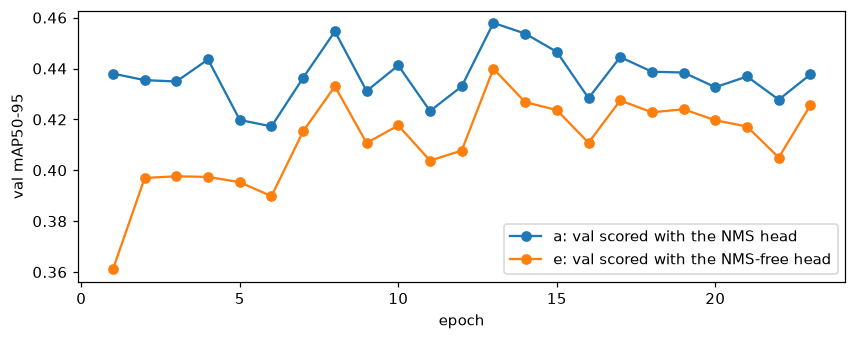

a: best epoch 13 | test mAP50-95 NMS head 0.473, NMS-free head 0.455
e: best epoch 13 | test mAP50-95 NMS head 0.473, NMS-free head 0.455
cross-validated test mAP50-95: NMS head 0.464 +- 0.024, NMS-free head 0.429 +- 0.029


In [9]:
import csv
curves = {c: list(csv.DictReader(open(f"../results/cv/train/f0-{c}.csv"))) for c in ("a", "e")}
for c, label in (("a", "a: val scored with the NMS head"), ("e", "e: val scored with the NMS-free head")):
    plt.plot([int(r["epoch"]) for r in curves[c]], [float(r["metrics/mAP50-95(B)"]) for r in curves[c]], marker="o", label=label)
plt.xlabel("epoch"); plt.ylabel("val mAP50-95"); plt.legend(); plt.show()
h = json.loads(Path("../results/cv/hypothesis_e.json").read_text())
for c in ("a", "e"):
    print(f"{c}: best epoch {h[c]['epoch']:2d} | test mAP50-95 NMS head {h[c]['test_nms']:.3f}, NMS-free head {h[c]['test_e2e']:.3f}")
cv = {k: json.loads(Path(f"../results/cv/{k}.json").read_text())["detection"]["mAP50-95"] for k in ("finetuned_nms", "finetuned_e2e")}
print("cross-validated test mAP50-95: NMS head %.3f +- %.3f, NMS-free head %.3f +- %.3f" %
      (cv["finetuned_nms"]["mean"], cv["finetuned_nms"]["std"], cv["finetuned_e2e"]["mean"], cv["finetuned_e2e"]["std"]))

- Đầu ra một-một **thua ở mọi epoch**, không chỉ ở epoch được chọn. Khoảng cách thu hẹp dần khi huấn
  luyện lâu hơn (từ khoảng 8 điểm ở epoch 1 xuống khoảng 2 điểm ở epoch 13), nên nó đúng là học chậm hơn,
  nhưng không bắt kịp trước khi dừng sớm.
- Chọn epoch theo đầu ra một-một vẫn chọn **đúng epoch 13**, và vì cùng hạt giống, hai lần huấn luyện cho
  **trọng số giống hệt nhau**: dự đoán của a và e trùng nhau từng byte.
- Vậy giả thuyết "do chọn epoch theo đầu ra có NMS" **bị bác bỏ**. Khoảng cách vẫn còn sau kiểm định chéo:
  khoảng 3,5 điểm mAP50–95. Nguyên nhân thật (có thể là tốc độ học của đầu ra một-một khi đổi dữ liệu,
  hoặc cách Ultralytics cân hai hàm mất mát) dự án chưa tìm ra.

Hệ quả thực tế: sau fine-tune nên dùng đầu ra có NMS. NMS chỉ tốn khoảng 1 ms (notebook 06).

## Tóm tắt

- YOLO26 dự đoán **dày đặc**: 10.920 ô ở ba bước nhảy 8, 16, 32 cho một ảnh $1280\times416$; mỗi ô ra một khung và 80 điểm lớp.
- Gán một-nhiều khi học sinh ra trùng lặp (21 ứng viên cho 3 xe); **NMS** giữ khung điểm cao nhất
  mỗi cụm. Bản tự cài khớp torchvision và Ultralytics.
- Đầu ra **một-một** học cách không trùng lặp nên bỏ được NMS; với trọng số COCO nó ngang đầu ra có NMS.
- Fine-tune toàn bộ từ trọng số COCO: mAP val đi ngang ngay từ epoch 1, epoch 4 được chọn theo đầu ra có NMS.
- Sau fine-tune, đầu ra một-một thua (0,451 so với 0,477) và kéo nhiều khung chạm mép dưới. Giả thuyết
  "do chọn epoch" đã được kiểm chứng và bị bác bỏ: đầu ra một-một thua ở mọi epoch; nguyên nhân thật chưa rõ.